# FORCE Learning with Recursive Least Squares (RLS) in Chaotic RNNs

We'll teach a randomly-wired, chaotic RNN to produce a smooth, periodic signal using FORCE learning. FORCE stands for **First-Order Reduced and Controlled Error**. It's a mouthful. As you know, all training is mostly about minimizing some cost function while tweaking the model parameters. In other words, reducing the error as much as possible. The goal of FORCE learning algorithm is not to find the shortest path to significant error reduction, but rather *reducing the amount of modification needed to keep the errors small*. Another way FORCE differs from the way most neural networks are trained is that weights are updated immediately and incrementally after seeing each new data point. This method is called online learning in contrast to offline learning where the model sees all the training data in advance.

## RNN

Let's build a vanilla recurrent neural network (RNN) with randomly connected units. It receives no external inputs and has no output readout mechanism. Just the neurons feeding of their own internal chaos.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# ----------------
# Parameters
# ----------------

# network size and connectivity
N =  30  # number of neurons
p = 0.1   # sparsity of recurrent connections
g = 1.5   # gain parameter controlling chaos

# Time constants
dt = 0.1  # integration timestep (ms)
T = 1000  # total simulation time (ms)
steps = int(T / dt)  # number of timesteps

In [5]:
# ---------------------------
# Initialize RNN
# ---------------------------

def init_rnn(N: int, p: float, g: float):
    """
    Initialize a random recurrent neural network (RNN) with given parameters.
    
    Parameters
    ----------
    N : int
        Number of neurons in the RNN.
    p : float
        Sparsity of recurrent connections (probability of connection).
    g : float
        Gain parameter controlling the level of chaos in the network.
    
    Returns
    -------
    J : np.ndarray
        Random recurrent weight matrix.
    """
    # Randomly initialize recurrent weights with sparsity p.
    # J is a NxN matrix where each entry is either 0 or a random weight.
    # It defines how neurons are connected to each other. Each element J[i, j]
    # represents the strength of the connection from neuron j to neuron i.
    J = np.random.rand(N, N) < p
    J = J.astype(float)  # convert boolean mask to float
    J *= np.random.randn(N, N)  # scale by random weights
    J *= g  # apply gain factor

    # A note on scaling:
    # The normalization factor (1 / sqrt(p * N)) ensures that each neuron's input remains balanced
    # as the network size grows. Without this scaling, the summed input to each neuron could become
    # too large (exploding activity) or too small (vanishing dynamics), especially in large, dense networks.
    scale = 1.0 / np.sqrt(p * N) 
    J *= scale

    return J

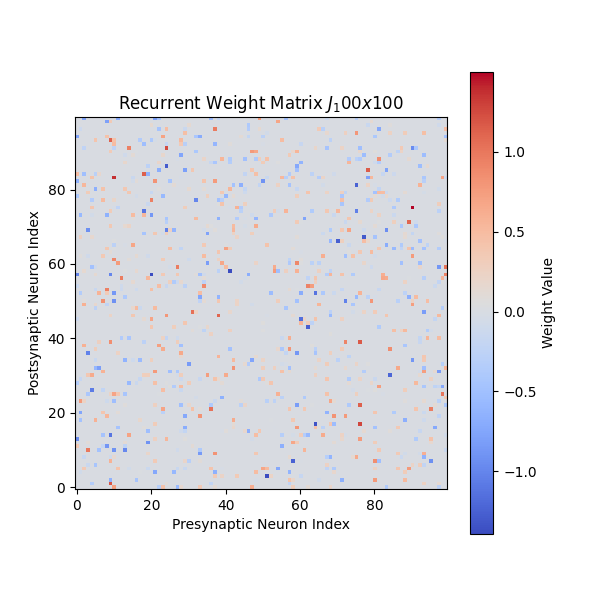

In [66]:
J = init_rnn(N, p, g)

plt.figure(figsize=(6, 6))
plt.imshow(J, cmap='coolwarm', origin="lower")
plt.colorbar(label='Weight Value')
plt.title(f'Recurrent Weight Matrix $J_{N}x{N}$')
plt.xlabel('Presynaptic Neuron Index')
plt.ylabel('Postsynaptic Neuron Index')
plt.show()

In [7]:
# ---------------------------
# Simulate RNN without learning
# ---------------------------

def run_rnn(J: np.ndarray, T: int, dt: float):
  """
  Simulate network activity with no learning for a set duration.
  """
  steps = int(T / dt)
  N = J.shape[0]
  x = 0.5 * np.random.randn(N) # initial network activity
  r = np.tanh(x)

  r_history = np.zeros((steps, N))  # to store activity over time
  for t in range(steps):
    dx = dt * (-x + J @ r)
    x += dx
    r = np.tanh(x)
    r_history[t] = r
  
  return r_history

We expect the network to exhibit rich, high-dimensional dynamics. Does it? Try playing with the parameters. Especially, notice what happens at different scales of sparsity or gain factor.

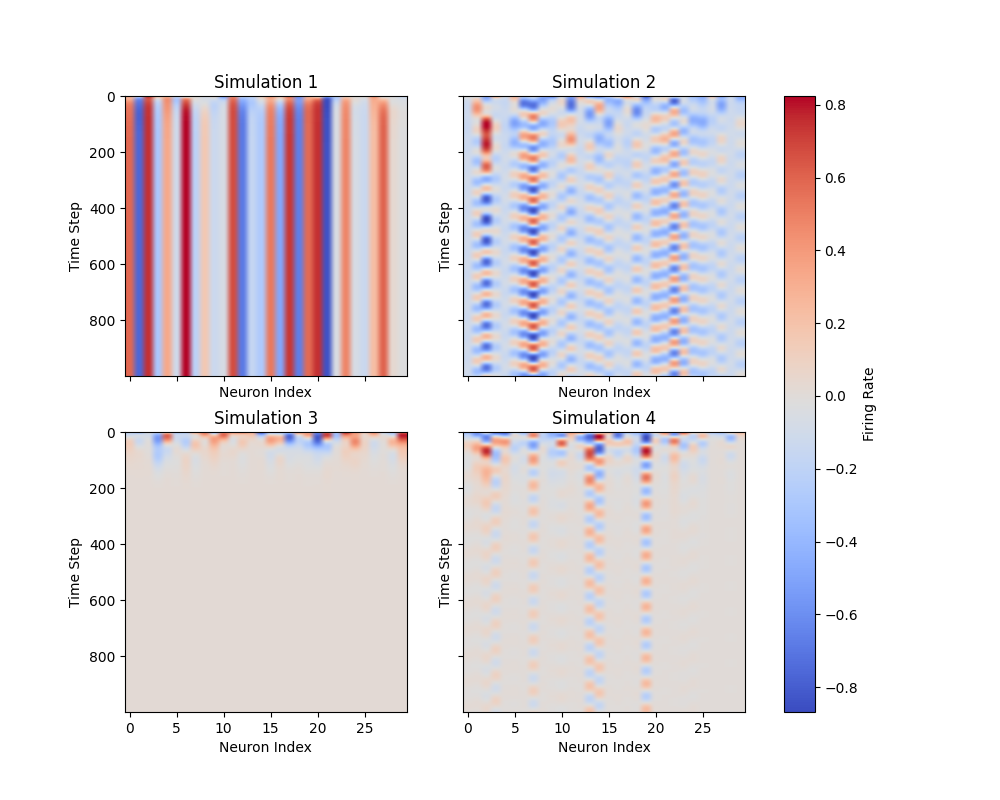

In [44]:
# ---------------------------
# Run and Visualize
# ---------------------------

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten for easy iteration

# Plot each simulation
for i in range(4):
    J = init_rnn(N, p, g)
    r_history = run_rnn(J, T, dt)
    im = axes[i].imshow(r_history, aspect='auto', cmap='coolwarm')
    axes[i].set_xlabel('Neuron Index')
    axes[i].set_ylabel('Time Step')
    axes[i].set_title(f'Simulation {i+1}')

fig.colorbar(im, ax=axes, label='Firing Rate')
plt.show()

## Defining a Target Signal

Let's give the network something to learn. Can it learn to reproduce a clean, structured signal on its own? We'll feed the signal during training and then watch it generate the pattern from its internal dynamics.

### First Target: Triangle Wave

In [ ]:
def triangle_wave(t, period=200):
    return 2 * np.abs(2 * ((t / period) % 1) - 1) - 1

### Optional Target: Sum of Sines

In [56]:
def sum_of_sines(t, period=200):
    amp = 1.3
    freq = 1 / period
    f1 = (amp / 1.0) * np.sin(1.0 * np.pi * freq * t)
    f2 = (amp / 2.0) * np.sin(2.0 * np.pi * freq * t)
    f3 = (amp / 6.0) * np.sin(3.0 * np.pi * freq * t)
    f4 = (amp / 3.0) * np.sin(4.0 * np.pi * freq * t)
    return (f1 + f2 + f3 + f4) / 1.5

#### Generate and Visualize Target

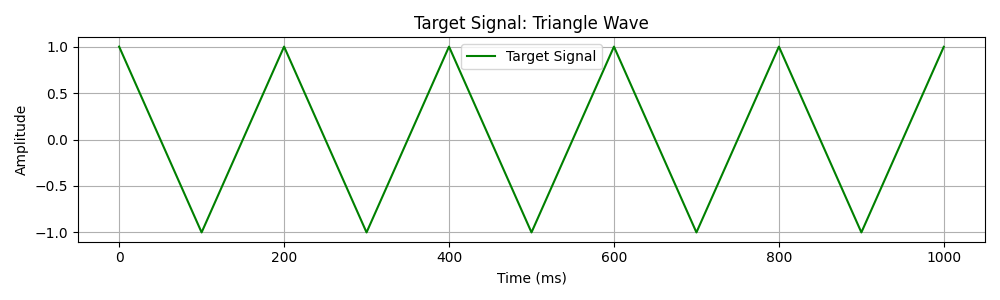

In [58]:
timesteps = np.arange(0, T, dt)

f_target = triangle_wave(timesteps, period=200)

plt.figure(figsize=(10, 3))
plt.plot(timesteps, f_target, color='green', label='Target Signal')
plt.title('Target Signal: Triangle Wave')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

We defined a simple target signal for our RNN to learn. Triangle wave is simple, interpretable, and easy to debug. We can swap in a complex signal (like sum-of-sines) once we're confident in FORCE learning.

## FORCE Learning

I am still struggling to wrap my mind around it. In the original Susillo & Abbott paper, FORCE learning isn't just about mapping neuron activity to a target. It's about harnessing the internal chaos of randomly wired RNN and feeding just enough information back into it to keep on track. By design, they're not supposed to inject any structured input into the network. The surprising part to me is that they don't train the network weights $J$. What they're actually learning is a readout, and feed that output back into the network.

In the last sections, we:
- built a vanilla recurrent network (no learning)
- watched its neurons do their own thing
- defined a target signal we want it to generate (like a triangle wave)

The network is just bouncing arount as it wants. We want to make it track a specific output without destroying its internal richness.

Recall the dynamics of our vanilla RNN. 
```python
dx = dt * (-x + J @ r)
```  
Treating the RNN as a self-contained system (spoilers: no feedback unit), we'll apply learning directly to the internal recurrent connections. $J$ becomes learnable. We'll update it every other time step using the output error.

### FORCE Learning: Step by Step

1. Compute the output:
$$
\begin{equation}
z(t) = {w}_{\text{out}}^\top \cdot {r}(t)
\end{equation}
$$

2. Compare to the target:
$$
\begin{equation}
e(t) = z(t) - f(t)
\end{equation}
$$

3. Use RLS to compute a fast weight update for the output weights.

4. Then use that same update to nudge all internal weights in \( J \):
$$
\begin{equation}
J \leftarrow J + \Delta {w}_{\text{out}}^\top
\end{equation}
$$

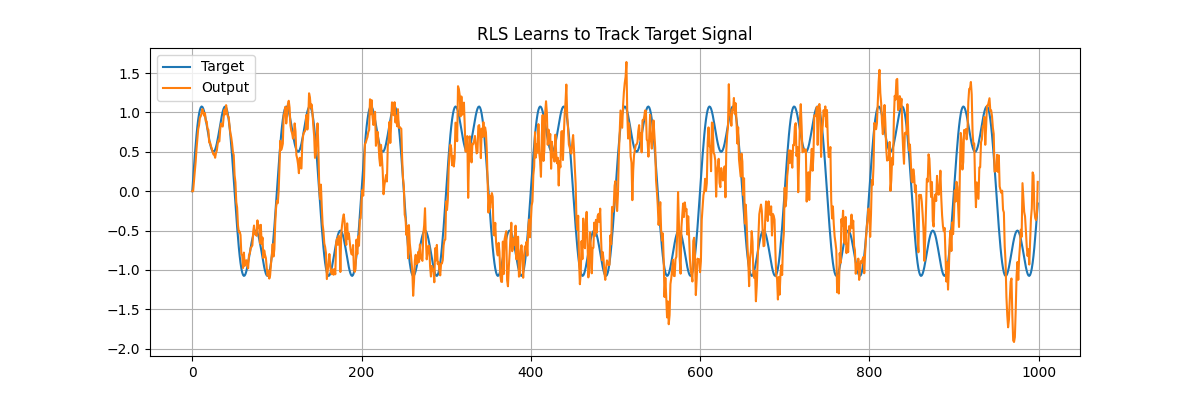

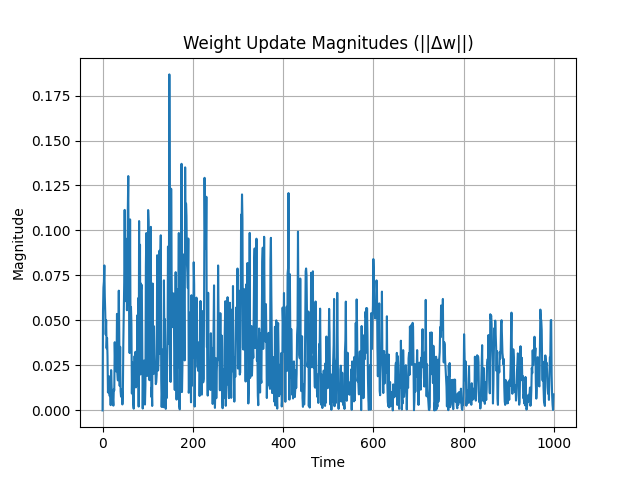

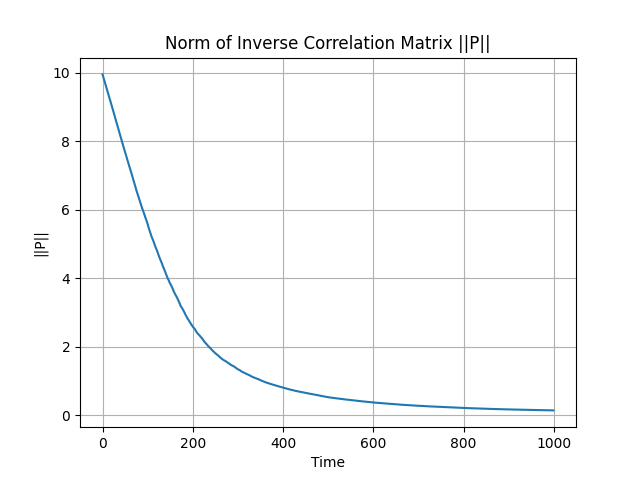

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters
N = 100          # number of features (inputs)
T = 1000         # number of time steps
alpha = 1.0      # regularization

# --- Generate fake neural inputs
r = np.random.randn(T, N) * 0.2
for i in range(1, T):
    r[i] += 0.95 * r[i-1]  # temporal smoothing

# --- Target signal (sum of sinusoids)
time = np.arange(T)
f = np.sin(0.02 * np.pi * time) + 0.5 * np.sin(0.06 * np.pi * time)

# --- Init RLS
w = np.zeros(N)
P = (1.0 / alpha) * np.eye(N)

# --- Track output and weight updates
z_out = np.zeros(T)
update_mags = []
P_norms = []

for t in range(T):
    z = w @ r[t]
    error = z - f[t]
    k = P @ r[t]
    c = 1.0 / (1.0 + r[t] @ k)
    P -= np.outer(k, k) * c
    dw = -error * k * c
    w += dw

    z_out[t] = z
    update_mags.append(np.linalg.norm(dw))
    P_norms.append(np.linalg.norm(P))

# --- Plot results
plt.figure(figsize=(12, 4))
plt.plot(f, label='Target')
plt.plot(z_out, label='Output')
plt.title('RLS Learns to Track Target Signal')
plt.legend()
plt.grid(True)
plt.show()

# --- Visualize update magnitudes
plt.figure()
plt.plot(update_mags)
plt.title('Weight Update Magnitudes (||Δw||)')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# --- Visualize contraction of P
plt.figure()
plt.plot(P_norms)
plt.title('Norm of Inverse Correlation Matrix ||P||')
plt.xlabel('Time')
plt.ylabel('||P||')
plt.grid(True)
plt.show()
